In [8]:
using Jens, Cosmology, Statistics, LinearAlgebra, Random, Printf, Plots
using Jens.LensShapelet: ShapeletBasis, n_basis, build_design,
    solve_coeffs, shapelet_model, build_reg_matrix
using Jens.LensMH: lens_mh_multistart, lens_mh, chain, chain_stats

Random.seed!(42)

TaskLocalRNG()

# Previous work

In [9]:
cosmo = Cosmology.FlatLCDM(0.7, 0.3, 0.0, 0.0)
grid  = Jens.LensGenerator.GenGrid(pix_n=64)

Jens.LensGenerator.Grid(64, 0.09, [-2.88 -2.88 … -2.88 -2.88; -2.79 -2.79 … -2.79 -2.79; … ; 2.79 2.79 … 2.79 2.79; 2.88 2.88 … 2.88 2.88], [-2.88 -2.79 … 2.79 2.88; -2.88 -2.79 … 2.79 2.88; … ; -2.88 -2.79 … 2.79 2.88; -2.88 -2.79 … 2.79 2.88])

In [18]:
THETA_E_TRUE = 0.8    # Einstein radius
BETA_TRUE    = 0.10   # shapelet scale
NMAX_TRUE    = 6      # shapelet base
SRC_X_TRUE   = 0.03   
SRC_Y_TRUE   = 0.02   
SIGMA_NOISE  = 0.003
n_basis_true = (NMAX_TRUE + 1) * (NMAX_TRUE + 2) ÷ 2

28

In [19]:
lens_truth = Jens.LensBase.SingleModel(
    Jens.LensModel.SIS.SIS;
    theta_E=THETA_E_TRUE, xcentre=0.0, ycentre=0.0)

sys_truth = Jens.LensSystem.ForwardModel(;
    lens_plane   = Jens.LensGenerator.LensedPlane(
        lens_truth; z_lens=0.3, cosmology=cosmo),
    source_plane = Jens.LightModel.ExtendedSource(
        Jens.LightModel.GaussianLight.GaussianSphere;
        amp=1.0, sigma=0.01),
    grid         = grid,
    z_source     = 1.5,
)

Jens.LensSystem.ForwardModel{Jens.LensGenerator.LensedPlane{Jens.LensBase.SingleModel{Module, @NamedTuple{theta_E::Float64, xcentre::Float64, ycentre::Float64}}, Cosmology.FlatLCDM{Float64}}, Jens.LensGenerator.LightPlane{Jens.LightModel.ExtendedSource{typeof(Jens.LightModel.GaussianLight.GaussianSphere), @NamedTuple{amp::Float64, sigma::Float64}}}, Nothing, Jens.LensGenerator.Grid, Nothing}(Jens.LensGenerator.LensedPlane{Jens.LensBase.SingleModel{Module, @NamedTuple{theta_E::Float64, xcentre::Float64, ycentre::Float64}}, Cosmology.FlatLCDM{Float64}}(Jens.LensBase.SingleModel{Module, @NamedTuple{theta_E::Float64, xcentre::Float64, ycentre::Float64}}(Jens.LensModel.SIS, (theta_E = 0.8, xcentre = 0.0, ycentre = 0.0)), 0.3, Cosmology.FlatLCDM{Float64}(0.7, 0.3, 0.0, 0.0)), Jens.LensGenerator.LightPlane{Jens.LightModel.ExtendedSource{typeof(Jens.LightModel.GaussianLight.GaussianSphere), @NamedTuple{amp::Float64, sigma::Float64}}}(Jens.LightModel.ExtendedSource{typeof(Jens.LightModel.Gaussi

In [20]:
mask = Jens.LensMask.circular_mask(grid, 2.0)
mask_idx = findall(vec(mask))
n_pix = length(mask_idx)

basis_true = ShapeletBasis(NMAX_TRUE, BETA_TRUE)
tmp_data = zeros(size(grid.xg))

A_masked_true, A_conv_true, _ = build_design(
    sys_truth, basis_true, tmp_data, mask;
    xc_src=SRC_X_TRUE, yc_src=SRC_Y_TRUE)

c_truth = randn(n_basis_true) .* 0.3
c_truth[1] = 1.0      # DC (total flux)
c_truth[2] = 0.3      # dipole x
c_truth[3] = -0.2     # dipole y

-0.2

In [21]:
basis_true = ShapeletBasis(NMAX_TRUE, BETA_TRUE)
tmp_data = zeros(size(grid.xg))

A_masked_true, A_conv_true, _ = build_design(
    sys_truth, basis_true, tmp_data, mask;
    xc_src=SRC_X_TRUE, yc_src=SRC_Y_TRUE)

([1.7800545383820504e-41 -3.438406800105469e-40 … 6.601274362826577e-40 -6.215307646052595e-41; 8.519348046101526e-41 -1.6417188268834828e-39 … -3.1772785304965624e-39 -9.137971553909514e-41; … ; 3.809281791343559e-38 7.125181395893415e-37 … 7.821561747704713e-38 3.2721367600077623e-38; 1.165941351786168e-38 2.186211724591285e-37 … -4.297733625726722e-37 -1.3664636515072228e-38], [3.492140730240406e-261 -1.2087065001668392e-259 … 5.547840539265813e-253 2.2647048303867538e-253; 9.623129144649854e-252 -3.321078987642817e-250 … 1.2836199249968834e-243 5.076723555795915e-244; … ; 1.9841385987192243e-241 6.735305195156603e-240 … 2.2894997152000753e-233 8.971165604225921e-234; 1.2172515815886672e-250 4.144316556921241e-249 … 1.6803397143490264e-242 6.801645929790488e-243], [680, 681, 682, 683, 684, 685, 686, 741, 742, 743  …  3483, 3484, 3485, 3540, 3541, 3542, 3543, 3544, 3545, 3546])

In [23]:
c_truth = randn(n_basis_true) .* 0.3
c_truth[1] = 1.0                                  # DC component
# Set a few low-order modes
c_truth[2] = 0.3                                  # n1=1,n2=0 → dipole x
c_truth[3] = -0.2   

# Render truth image
data_true = reshape(A_conv_true * c_truth, size(grid.xg))
data_true_max = maximum(abs, data_true)
data_true ./= data_true_max                        # normalise to ~1

# Re-render with normalised coefficients
c_truth ./= data_true_max
data_true = reshape(A_conv_true * c_truth, size(grid.xg))

# Add noise
data = data_true .+ SIGMA_NOISE .* randn(size(data_true))
snr = maximum(data[mask]) / SIGMA_NOISE

334.7815225879863

# MCMC

In [30]:
SHAPELET_NMAX_MCMC = NMAX_TRUE    # must = truth for well-specified model
N_MCMC = (SHAPELET_NMAX_MCMC + 1) * (SHAPELET_NMAX_MCMC + 2) ÷ 2


28

In [ ]:
function shapelet_logp(params)
    return Base.invokelatest(params) do p
        theta_E,beta,xc_src,yc_src  = p

        # Hard bounds (prior)
        if theta_E < 0.1 || theta_E > 2.5 ||
           beta < 0.01 || beta > 0.50 ||
           abs(xc_src) > 0.3 || abs(yc_src) > 0.3
            return -Inf
        end

        lens = Jens.LensBase.SingleModel(
            Jens.LensModel.SIS.SIS;
            theta_E=theta_E, xcentre=0.0, ycentre=0.0)

        sys = Jens.LensSystem.ForwardModel(;
            lens_plane   = Jens.LensGenerator.LensedPlane(
                lens; z_lens=0.3, cosmology=cosmo),
            source_plane = Jens.LightModel.ExtendedSource(
                Jens.LightModel.GaussianLight.GaussianSphere;
                amp=1.0, sigma=0.01),
            grid         = grid,
            z_source     = 1.5,
        )

        b = ShapeletBasis(SHAPELET_NMAX_MCMC, beta)

        # build_design needs data for mask handling (not used otherwise)
        A_masked, _, _ = build_design(sys, b, data, mask;
                                       xc_src=xc_src, yc_src=yc_src)

        _, chi2 = solve_coeffs(A_masked, data, mask_idx, SIGMA_NOISE;
                                lambda=0.01)

        return -chi2 / 2
    end
end

shapelet_logp (generic function with 1 method)

In [32]:
#         θ_E    β       xc_src   yc_src
lower = [0.3,   0.03,    -0.15,  -0.15]
upper = [2.0,   0.30,     0.15,   0.15]
#
n_params = length(lower)

4

In [33]:
result = lens_mh_multistart(shapelet_logp, lower, upper;
                             n_starts=24, n_warmup=1500, n=2000, seed=42)


Jens.LensMH.MHResult([0.801861840863867 0.801861840863867 … 0.8010120795540859 0.8004552831637834; 0.08989544796749548 0.08989544796749548 … 0.08804955707397484 0.08800854732409379; 0.07606174349955223 0.07606174349955223 … 0.08778988151058607 0.08803991357511289; -0.08106975486907482 -0.08106975486907482 … -0.07494553918243198 -0.07522421560252959], [-3.885127543443024e6, -3.885127543443024e6, -3.885127543443024e6, -3.885127543443024e6, -3.885127543443024e6, -3.885127543443024e6, -3.885127543443024e6, -3.885127543443024e6, -3.885127543443024e6, -3.885127543443024e6  …  -3.8851086790427445e6, -3.885108318376804e6, -3.885108318376804e6, -3.885108898402669e6, -3.8851080158413616e6, -3.8851081778980596e6, -3.8851085959497876e6, -3.885109202332681e6, -3.885109202332681e6, -3.885108726072507e6], 905, [0.0012901096147986393, 0.00020489976235037202, 0.0002276664026115249, 0.0002276664026115249])

In [34]:
samples = chain(result; burn=500)
means, stds = chain_stats(result; burn=500)

([0.8000532241228493, 0.08831265410454323, 0.0872644159627515, -0.07449132127701402], [0.0006556874369039934, 0.0004076062634310979, 0.0012222516862559383, 0.001041874869906197])

# Results

In [35]:
using StatsPlots,PairPlots, MCMCChains, CairoMakie

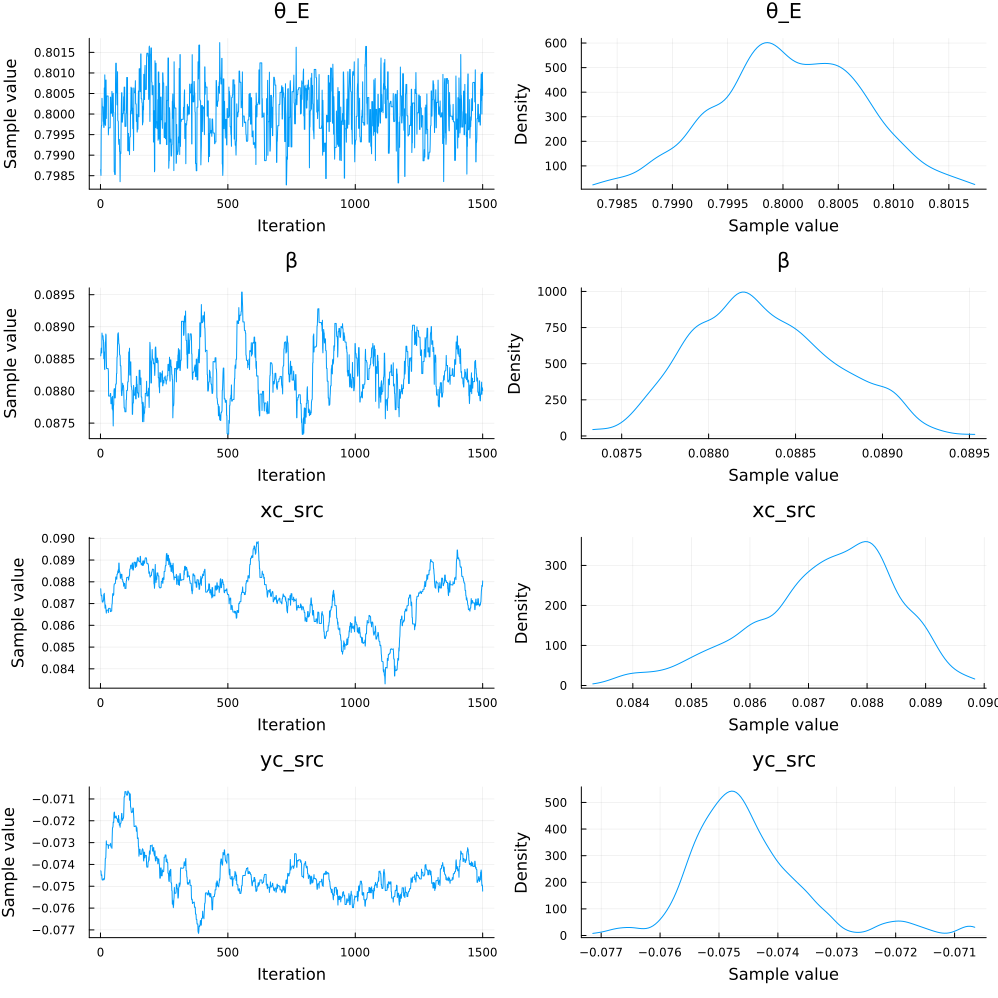

In [40]:
chn = Chains(samples', [:θ_E,  :β, :xc_src, :yc_src])
ChainPlot = StatsPlots.plot(chn) 

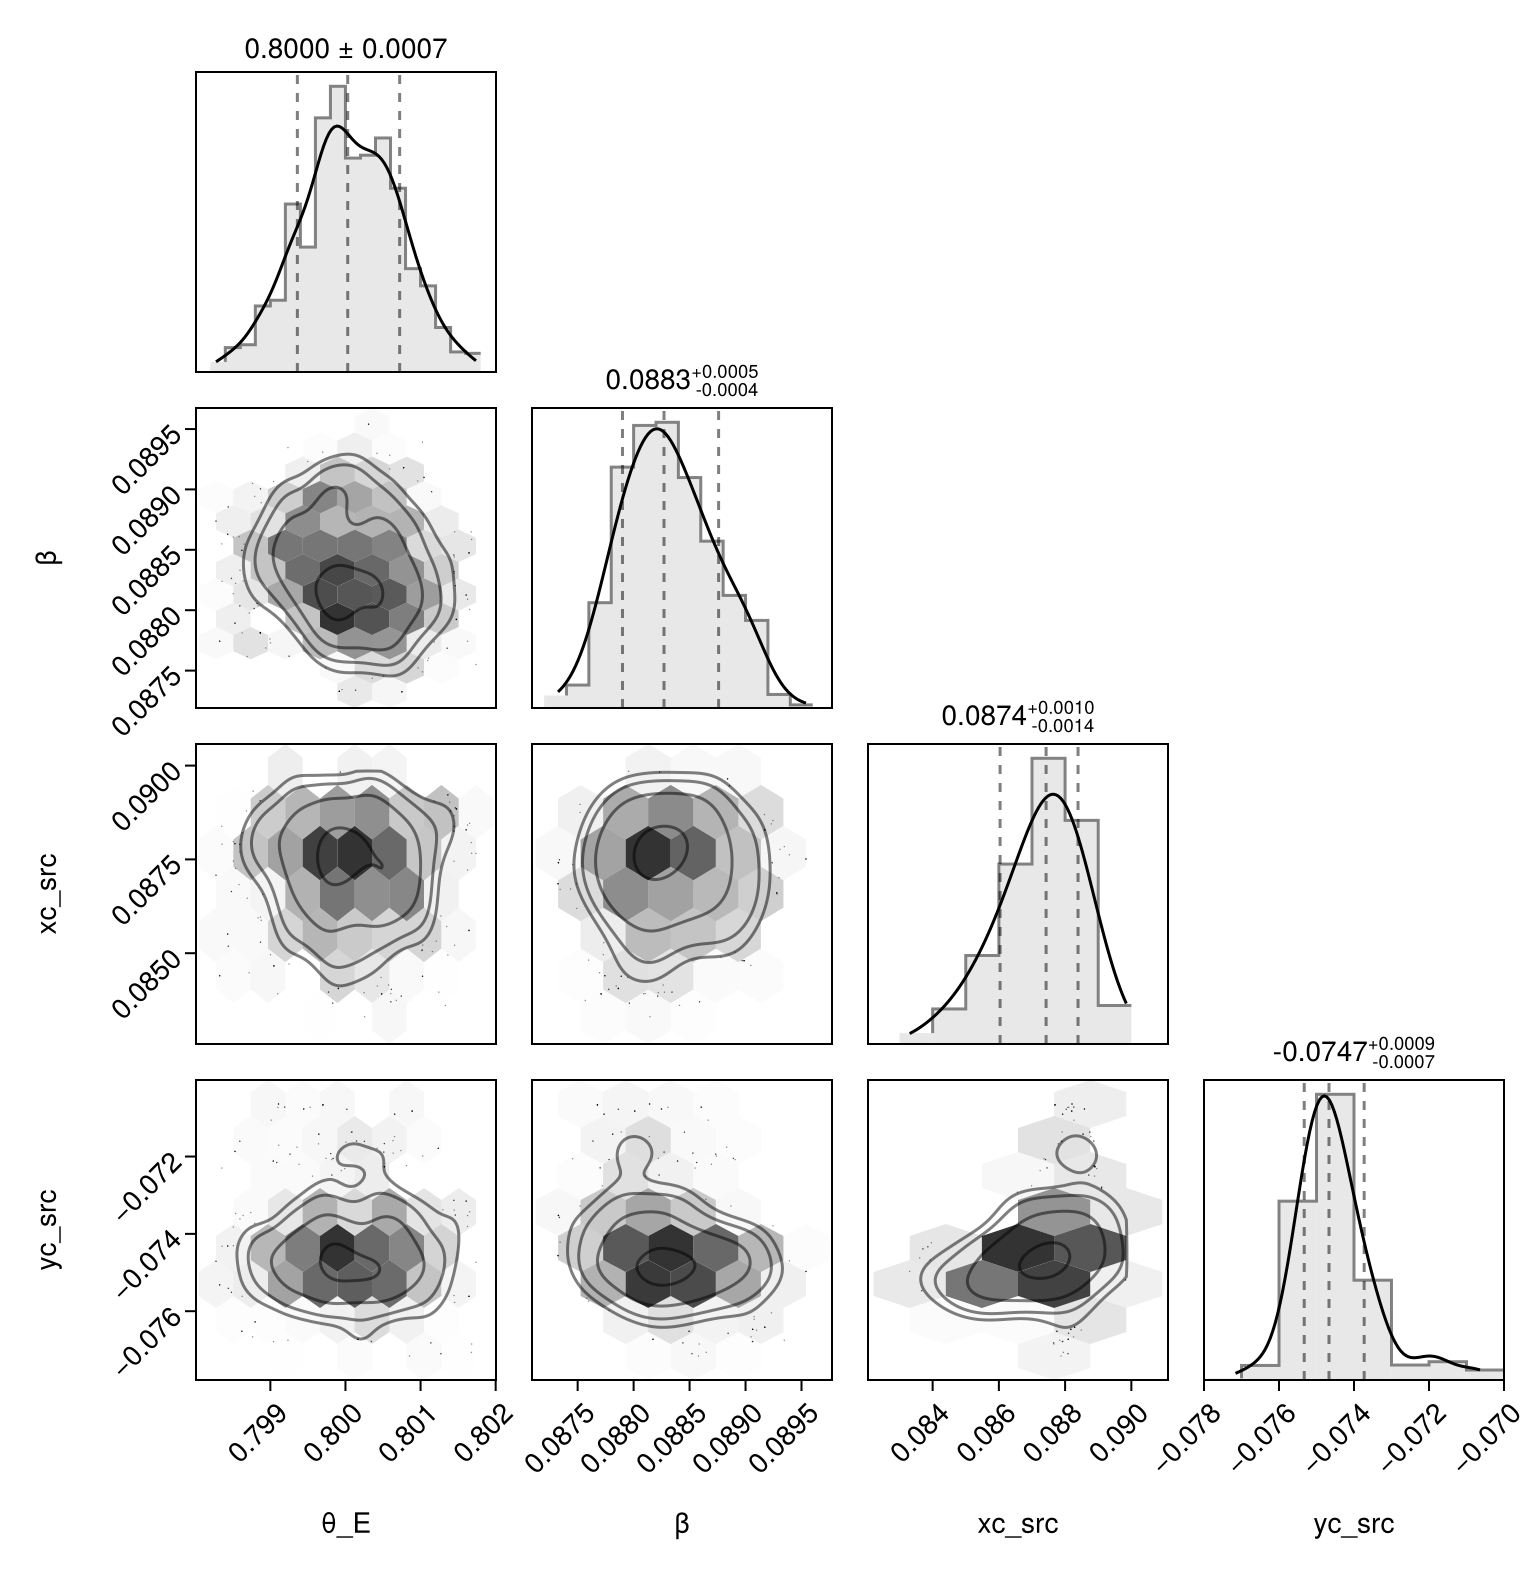

In [41]:
corner_fig = PairPlots.pairplot(chn)

In [42]:
65/84

0.7738095238095238